# Morphological inference of pedestrian alleys in favelas
## Article discussion notebook

---

**Authors**

Fernando Gomes  
Mariana Giannotti  
Diego Bogado Tomasiello

University of São Paulo

---

This notebook documents the evolution of the project after the first manuscript submission. It summarizes methodological changes, large-scale processing results and exploratory analyses that will support the next version of the manuscript.

# 0. Evolution of the framework

## Research question

**How did the project evolve after the first manuscript?**

The original manuscript focused on extracting pedestrian alley networks from airborne LiDAR.

During the review process and the large-scale processing of São Paulo favelas, the project evolved into a broader framework for the morphological characterization of pedestrian space.

## Original manuscript

Airborne LiDAR

        │

        ▼

Height Above Ground (HAG)

        │

        ▼

Walkable Open Space

        │

        ▼

Distance Transform

        │

        ▼

Medial Axis

        │

        ▼

Pedestrian Network

        │

        ▼

Morphological Analysis

## Main conceptual evolution

The original manuscript proposed a method for **inferring pedestrian networks** from airborne LiDAR.

The current framework goes beyond network extraction by systematically **characterizing the morphology of pedestrian space** through multiple complementary descriptors.

In the current framework, the pedestrian network is no longer the final product.

It becomes an intermediate representation from which new urban indicators can be derived.

```mermaid
flowchart TD

A[Airborne LiDAR] --> B[HAG]
B --> C[Open Space]
C --> D[Distance Transform]
D --> E[Medial Axis]
E --> F[Centerline Refinement]
F --> G[Pedestrian Network]

G --> H[Width]
G --> I[Distance]
G --> J[Open Space]
G --> K[Built Volume]
G --> L[Temporal]
G --> M[Acquisition]
G --> N[Community Validation]
G --> O[OSM Validation]

H --> P[1712 favelas]
I --> P
J --> P
K --> P
L --> P
M --> P
N --> P
O --> P

P --> Q[5136 observations]
```

# 1. Framework outputs

The current framework produces outputs at three complementary levels.

Understanding these levels is essential before exploring the results.

## Framework outputs

```text
                             FRAMEWORK
                                  │
        ┌─────────────────────────┼─────────────────────────┐
        │                         │                         │
        ▼                         ▼                         ▼
   Pixel level              Network level             Favela level
   ------------             -------------             ------------

   Raster layers            Vector layers             Summary tables

   • HAG                    • Centerline              • General
   • Open space             • Pedestrian network      • Width
   • Width                  • Nodes                  • Distance
   • Distance               • Validation             • Built
   • Occupied HAG           • OSM                    • Acquisition
                                                      • Temporal
                                                      • Validation
                                                      • OSM
```

# 2. Research agenda

The objective of this notebook is not only to inspect the generated datasets, but to identify the most relevant scientific findings that may strengthen the manuscript.

## Main research questions

| ID | Question | Main datasets |
|----|----------|---------------|
| Q1 | How does pedestrian morphology vary among São Paulo favelas? | General, Centerline, Width |
| Q2 | How did pedestrian morphology change between 2017 and 2020? | Temporal |
| Q3 | How sensitive is the framework to LiDAR acquisition characteristics? | Acquisition |
| Q4 | How compatible is the inferred network with external references? | Validation, OSM |
| Q5 | Which descriptors best characterize each favela? | All summaries |

## Expected scientific contributions

Before exploring the data, it is useful to distinguish between expected results and potentially novel findings.

Expected findings include:

- different pedestrian morphologies among favelas;
- temporal changes between 2017 and 2020;
- differences in built volume and open space.

Potentially novel findings may include:

- systematic effects of LiDAR acquisition on inferred pedestrian networks;
- city-scale characterization of pedestrian morphology;
- relationships among morphological descriptors;
- typologies of informal settlements based on pedestrian structure.

# 3. Dataset overview

In [1]:
from pathlib import Path

import geopandas as gpd

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from pandas.plotting import scatter_matrix

import seaborn as sns

In [2]:
SUMMARY = Path("output/summary")

In [3]:
datasets = {
    "general": "general_summary.csv",
    "centerline": "centerline_summary.csv",
    "acquisition": "acquisition_summary.csv",
    "built": "built_summary.csv",
    "distance": "distance_summary.csv",
    "width": "width_summary.csv",
    "open_space": "open_space_summary.csv",
    "temporal": "temporal_summary.csv",
    "validation": "validation_summary.csv",
    "osm": "osm_summary.csv",
}

In [4]:
tables = {}

for name, file in datasets.items():
    df = pd.read_csv(SUMMARY / file)
    tables[name] = df

In [5]:
descriptions = {
    "general": "General descriptors",
    "centerline": "Network morphology",
    "acquisition": "LiDAR acquisition",
    "built": "Built environment",
    "distance": "Distance metrics",
    "width": "Alley width metrics",
    "open_space": "Open-space metrics",
    "temporal": "2017–2020 comparison",
    "validation": "Community validation",
    "osm": "OpenStreetMap comparison",
}

overview = pd.DataFrame(
    [
        {
            "Dataset": name,
            "Rows": len(df),
            "Columns": len(df.columns),
            "Description": descriptions[name],
        }
        for name, df in tables.items()
    ]
)

overview

,Dataset,Rows,Columns,Description
0,general,5136,4,General descriptors
1,centerline,5136,47,Network morphology
2,acquisition,5136,18,LiDAR acquisition
3,built,5136,13,Built environment
4,distance,5136,12,Distance metrics
5,width,5136,12,Alley width metrics
6,open_space,5136,6,Open-space metrics
7,temporal,1712,2,2017–2020 comparison
8,validation,5136,2,Community validation
9,osm,5136,17,OpenStreetMap comparison


# 4. Dataset inventory

In [6]:
for name, df in tables.items():
    print("=" * 80)
    print(name.upper())
    print("=" * 80)

    for col in df.columns:
        print(col)

GENERAL
favela
year
area_m2
perimeter_m
CENTERLINE
favela
year
segments_total
segments_tail
segments_short_tail
segments_kept
tail_ratio
network_length
alley_length
street_length
alley_ratio
segment_length_mean
segment_length_median
segment_length_std
segment_length_min
segment_length_max
segment_length_p05
segment_length_p25
segment_length_p75
segment_length_p95
width_mean
width_median
width_std
width_min
width_max
width_p05
width_p25
width_p75
width_p95
distance_mean
distance_median
distance_std
distance_min
distance_max
distance_p05
distance_p25
distance_p75
distance_p95
context_height_mean
context_height_median
context_height_std
context_height_min
context_height_max
context_height_p05
context_height_p25
context_height_p75
context_height_p95
ACQUISITION
favela
year
total_points
points_per_m2
ground_points
ground_points_per_m2
ground_percentage
returns_mean
returns_median
first_return_points
first_return_density
first_return_percentage
scan_min
scan_max
scan_range
scan_abs_mean
scan

In [7]:
for name, df in tables.items():
    print(f"\n{name.upper()}")
    display(pd.DataFrame({"Variable": df.columns}))


GENERAL


,Variable
0,favela
1,year
2,area_m2
3,perimeter_m



CENTERLINE


,Variable
0,favela
1,year
2,segments_total
3,segments_tail
4,segments_short_tail
5,segments_kept
6,tail_ratio
7,network_length
8,alley_length
9,street_length



ACQUISITION


...

,Variable
0,favela
1,year



VALIDATION


,Variable
0,favela
1,year



OSM


,Variable
0,favela
1,year
2,samples
3,mean
4,median
5,p90
6,maximum
7,within_0_5
8,within_1
9,within_2


In [8]:
tables["centerline"].head()

,favela,year,segments_total,segments_tail,segments_short_tail,segments_kept,tail_ratio,network_length,alley_length,street_length,...,distance_p95,context_height_mean,context_height_median,context_height_std,context_height_min,context_height_max,context_height_p05,context_height_p25,context_height_p75,context_height_p95
0,000001_fumaça,2017,2476,1224,0,1252,0.494346,3859.881525,1585.285782,1986.111597,...,11.715375,5.581944,3.655937,6.367305,2.646882,39.966915,2.961126,3.261874,4.980729,16.074074
1,000001_fumaça,2020,1149,587,0,562,0.510879,3467.030891,461.019819,2772.142105,...,21.947945,7.182776,4.458787,8.851526,2.132596,38.548267,2.292886,3.399932,6.076217,35.831488
2,000001_fumaça,2024,2068,1029,0,1039,0.497582,3618.923398,1557.860003,1858.840182,...,14.730139,6.985508,4.888443,7.569247,2.431814,40.757645,2.889106,3.198933,5.961751,24.468041
3,000002_manuel_antônio_portella,2017,3694,1798,0,1896,0.486735,9001.066162,3486.545036,4752.772144,...,13.583077,382.762724,4.150608,1970.942058,2.306639,10734.349609,2.724047,3.140137,7.119441,19.882190
4,000002_manuel_antônio_portella,2020,3086,1551,0,1535,0.502592,10920.506786,3081.251782,7116.865706,...,15.015821,5.116918,3.367141,3.891655,2.312825,24.823591,2.646771,2.914687,5.788805,13.727863


# 5. The pedestrian alley system of São Paulo's favelas

This section describes the overall morphology of the inferred pedestrian system before exploring differences among settlements or temporal changes.

In [9]:
centerline = (
    tables["centerline"]
    # .query("year == 2020")
    .copy()
)

centerline.head()

,favela,year,segments_total,segments_tail,segments_short_tail,segments_kept,tail_ratio,network_length,alley_length,street_length,...,distance_p95,context_height_mean,context_height_median,context_height_std,context_height_min,context_height_max,context_height_p05,context_height_p25,context_height_p75,context_height_p95
0,000001_fumaça,2017,2476,1224,0,1252,0.494346,3859.881525,1585.285782,1986.111597,...,11.715375,5.581944,3.655937,6.367305,2.646882,39.966915,2.961126,3.261874,4.980729,16.074074
1,000001_fumaça,2020,1149,587,0,562,0.510879,3467.030891,461.019819,2772.142105,...,21.947945,7.182776,4.458787,8.851526,2.132596,38.548267,2.292886,3.399932,6.076217,35.831488
2,000001_fumaça,2024,2068,1029,0,1039,0.497582,3618.923398,1557.860003,1858.840182,...,14.730139,6.985508,4.888443,7.569247,2.431814,40.757645,2.889106,3.198933,5.961751,24.468041
3,000002_manuel_antônio_portella,2017,3694,1798,0,1896,0.486735,9001.066162,3486.545036,4752.772144,...,13.583077,382.762724,4.150608,1970.942058,2.306639,10734.349609,2.724047,3.140137,7.119441,19.882190
4,000002_manuel_antônio_portella,2020,3086,1551,0,1535,0.502592,10920.506786,3081.251782,7116.865706,...,15.015821,5.116918,3.367141,3.891655,2.312825,24.823591,2.646771,2.914687,5.788805,13.727863


In [10]:
summary = pd.Series({

    "Number of favelas":
        len(centerline),

    "Total inferred network (km)":
        centerline.network_length.sum() / 1000,

    "Total alley candidates (<5 m) (km)":
        centerline.alley_length.sum() / 1000,

    "Mean alley candidates per favela (m)":
        centerline.alley_length.mean(),

    "Median alley candidates per favela (m)":
        centerline.alley_length.median(),

    "Mean alley width (m)":
        centerline.width_mean.mean(),

    "Median alley width (m)":
        centerline.width_median.median(),

})

summary.to_frame("Value")

,Value
Number of favelas,5136.000000
Total inferred network (km),11026.789401
Total alley candidates (<5 m) (km),5640.168899
Mean alley candidates per favela (m),1098.163727
Median alley candidates per favela (m),497.868264
Mean alley width (m),6.607226
Median alley width (m),4.000000


In [11]:
centerline["wide_network_length"] = (
    centerline["network_length"]
    - centerline["alley_length"]
)

In [12]:
(
    centerline[
        [
            "network_length",
            "alley_length",
            "wide_network_length",
        ]
    ]
    .sum() / 1000
).to_frame("km")

,km
network_length,11026.789401
alley_length,5640.168899
wide_network_length,5386.620501


In [13]:
# from statsmodels.distributions.empirical_distribution import ECDF

# ecdf = ECDF(centerline["alley_length"]/1000)

# plt.figure(figsize=(7,5))

# plt.plot(
#     ecdf.x,
#     ecdf.y,
# )

# plt.xlabel("Alley network length (km)")
# plt.ylabel("Cumulative proportion of favelas")

Text(0, 0.5, 'Alley network length (km)')

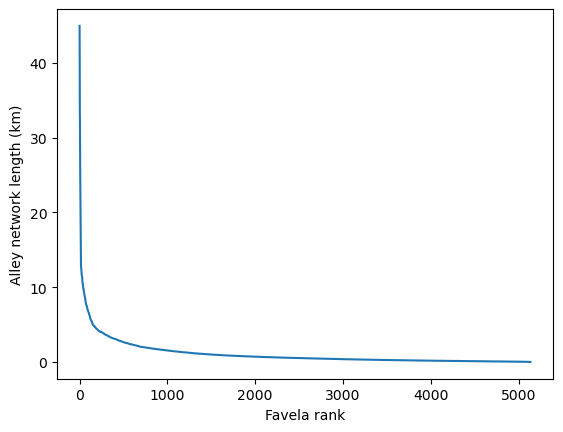

In [14]:
length = (
    centerline["alley_length"]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

plt.plot(
    length.values/1000
)

plt.xlabel("Favela rank")
plt.ylabel("Alley network length (km)")

Text(0, 0.5, 'Median alley width (m)')

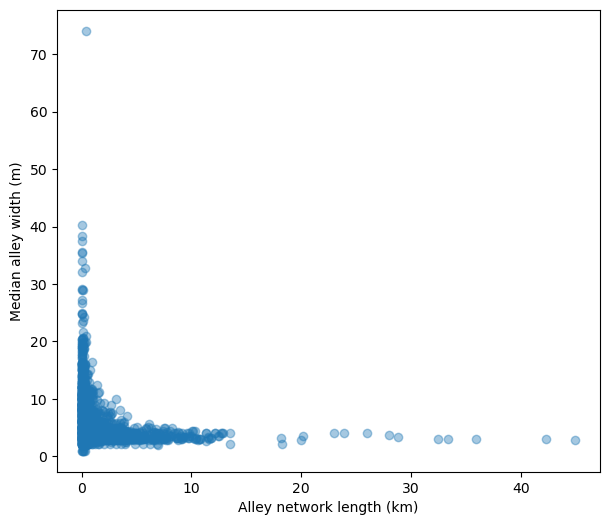

In [15]:
x = centerline["alley_length"] / 1000
y = centerline["width_median"]

plt.figure(figsize=(7,6))

plt.scatter(
    x,
    y,
    alpha=0.4,
)

plt.xlabel("Alley network length (km)")
plt.ylabel("Median alley width (m)")

In [16]:
centerline[
    [
        "network_length",
        "alley_length",
        "width_mean",
        "width_median",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
network_length,5136.0,2146.960553,3975.932812,0.0,423.232469,986.992047,2375.048721,69732.891474
alley_length,5136.0,1098.163727,2132.300093,0.0,193.211657,497.868264,1183.940008,44927.039453
width_mean,5135.0,6.607226,3.385255,2.0,4.914398,5.841132,7.213955,108.478550
width_median,5135.0,4.965797,3.210134,1.0,3.162278,4.000000,5.383358,74.060783


# 5. The observable alley system

In [17]:
centerline[
    [
        "favela",
        "alley_length",
        "network_length",
        "width_median",
    ]
].sort_values(
    "alley_length",
    ascending=False,
).head(20)

,favela,alley_length,network_length,width_median
639,000214_paraisópolis,44927.039453,69732.891474,2.914214
640,000214_paraisópolis,42306.805553,66741.109288,3.000000
641,000214_paraisópolis,35949.473570,60848.048702,3.000000
5119,001707_heliópolis,33338.113401,56664.895360,2.995352
2571,000858_boulevard_da_paz,32441.775295,57443.455668,3.081139
5118,001707_heliópolis,28828.690691,52954.272431,3.383914
114,000039_são_francisco_global,28026.549330,56096.503134,3.802776
115,000039_são_francisco_global,25983.852646,54613.128553,4.000000
116,000039_são_francisco_global,23878.957666,53419.008169,4.123106
5120,001707_heliópolis,23028.976427,46864.235291,4.000000


In [18]:
centerline[
    [
        "favela",
        "alley_length",
        "network_length",
        "width_median",
    ]
].sort_values(
    "alley_length"
).head(20)

,favela,alley_length,network_length,width_median
169,000057_morumbizinho_2,0.000000,1122.470757,34.058792
2899,000967_rodolfo_mozer,0.000000,40.795348,16.155495
76,000026_condessa_de_são_joaquim,0.000000,0.000000,NaN
467,000156_darzan,0.000000,10.874203,6.959653
66,000023_jd_wilson_i,0.000000,5.736409,6.034229
604,000202_rua_dos_crepis,0.000000,78.524472,13.882411
1947,000650_amaravati_praça,1.179919,18.881417,8.881774
2482,000828_tavanes_i,1.319017,55.716141,13.527548
1845,000616_leonardo_primavera,2.357404,71.488470,9.524938
226,000076_antenor_navarro,3.254042,9.096723,5.123106


In [19]:
cols = [

    "alley_length",

    "width_mean",

    "distance_mean",

    "context_height_mean",

]

centerline[cols].corr()

,alley_length,width_mean,distance_mean,context_height_mean
alley_length,1.000000,-0.125475,-0.115471,0.016658
width_mean,-0.125475,1.000000,0.991682,-0.009140
distance_mean,-0.115471,0.991682,1.000000,-0.008893
context_height_mean,0.016658,-0.009140,-0.008893,1.000000


In [20]:
centerline.nlargest(
    20,
    "width_mean",
)[
    [
        "favela",
        "width_mean",
        "alley_length",
    ]
]

,favela,width_mean,alley_length
4108,001370_guaicuri_i,108.478550,360.539109
2652,000885_clóvis_vaz_de_souza,40.572565,41.829107
168,000057_morumbizinho_2,39.798479,180.165299
2405,000802_dois,38.652984,49.064826
236,000079_ilha_verde,35.995385,35.766156
4309,001437_recanto_das_estrelas,35.802589,717.858596
4824,001609_jardim_comercial_i,32.965226,866.421872
169,000057_morumbizinho_2,32.787144,0.000000
1695,000566_rua_índia,32.225708,8.778972
1978,000660_anhanguera,31.754568,561.691550


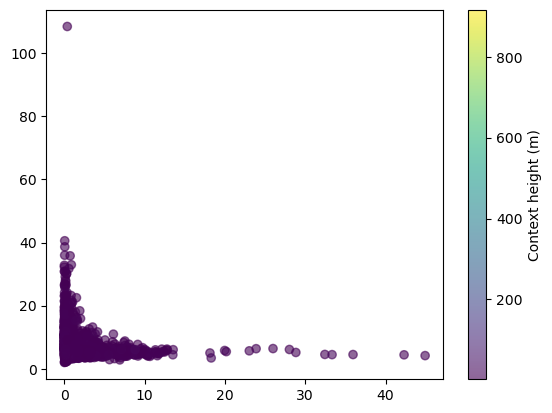

In [21]:
plt.scatter(

    centerline["alley_length"]/1000,

    centerline["width_mean"],

    c=centerline["context_height_mean"],

    alpha=.6,

)

plt.colorbar(
    label="Context height (m)"
)

In [22]:
centerline["alley_length"].describe(
    percentiles=[
        .10,
        .25,
        .50,
        .75,
        .90,
        .95,
        .99,
    ]
)

count     5136.000000
mean      1098.163727
std       2132.300093
min          0.000000
10%         85.555825
25%        193.211657
50%        497.868264
75%       1183.940008
90%       2581.121821
95%       3930.714021
99%       9161.810560
max      44927.039453
Name: alley_length, dtype: float64

# 5.4 Morphological descriptors

In [23]:
morphology = (
    tables["centerline"]
    .query("year == 2020")
    .merge(
        tables["built"],
        on=["favela","year"]
    )
    .merge(
        tables["open_space"],
        on=["favela","year"]
    )
    .merge(
        tables["general"],
        on=["favela","year"]
    )
)

In [24]:
cols = [

    "alley_length",

    "width_mean",

    "built_volume_m3",

    "open_space_area_m2",

    "context_height_mean",

]

morphology[cols].corr()

,alley_length,width_mean,built_volume_m3,open_space_area_m2,context_height_mean
alley_length,1.000000,-0.098137,0.725878,0.755588,0.173212
width_mean,-0.098137,1.000000,-0.052273,0.042312,-0.087487
built_volume_m3,0.725878,-0.052273,1.000000,0.597831,0.282865
open_space_area_m2,0.755588,0.042312,0.597831,1.000000,0.091095
context_height_mean,0.173212,-0.087487,0.282865,0.091095,1.000000


In [25]:
morphology["alley_density"] = (
    morphology["alley_length"]
    / morphology["area_m2"]
)

In [26]:
morphology["built_density"] = (
    morphology["built_volume_m3"]
    / morphology["area_m2"]
)

In [27]:
morphology["open_space_ratio"] = (
    morphology["open_space_area_m2"]
    / morphology["area_m2"]
)

In [28]:
cols = [

    "alley_density",

    "built_density",

    "open_space_ratio",

    "width_mean",

    "context_height_mean",

]

morphology[cols].corr()

,alley_density,built_density,open_space_ratio,width_mean,context_height_mean
alley_density,1.000000,0.642205,0.465783,-0.081759,-0.004848
built_density,0.642205,1.000000,0.266157,-0.208574,0.257927
open_space_ratio,0.465783,0.266157,1.000000,-0.038387,-0.057216
width_mean,-0.081759,-0.208574,-0.038387,1.000000,-0.087487
context_height_mean,-0.004848,0.257927,-0.057216,-0.087487,1.000000


array([[<Axes: xlabel='alley_density', ylabel='alley_density'>,
        <Axes: xlabel='built_density', ylabel='alley_density'>,
        <Axes: xlabel='open_space_ratio', ylabel='alley_density'>,
        <Axes: xlabel='width_mean', ylabel='alley_density'>,
        <Axes: xlabel='context_height_mean', ylabel='alley_density'>],
       [<Axes: xlabel='alley_density', ylabel='built_density'>,
        <Axes: xlabel='built_density', ylabel='built_density'>,
        <Axes: xlabel='open_space_ratio', ylabel='built_density'>,
        <Axes: xlabel='width_mean', ylabel='built_density'>,
        <Axes: xlabel='context_height_mean', ylabel='built_density'>],
       [<Axes: xlabel='alley_density', ylabel='open_space_ratio'>,
        <Axes: xlabel='built_density', ylabel='open_space_ratio'>,
        <Axes: xlabel='open_space_ratio', ylabel='open_space_ratio'>,
        <Axes: xlabel='width_mean', ylabel='open_space_ratio'>,
        <Axes: xlabel='context_height_mean', ylabel='open_space_ratio'>],
    

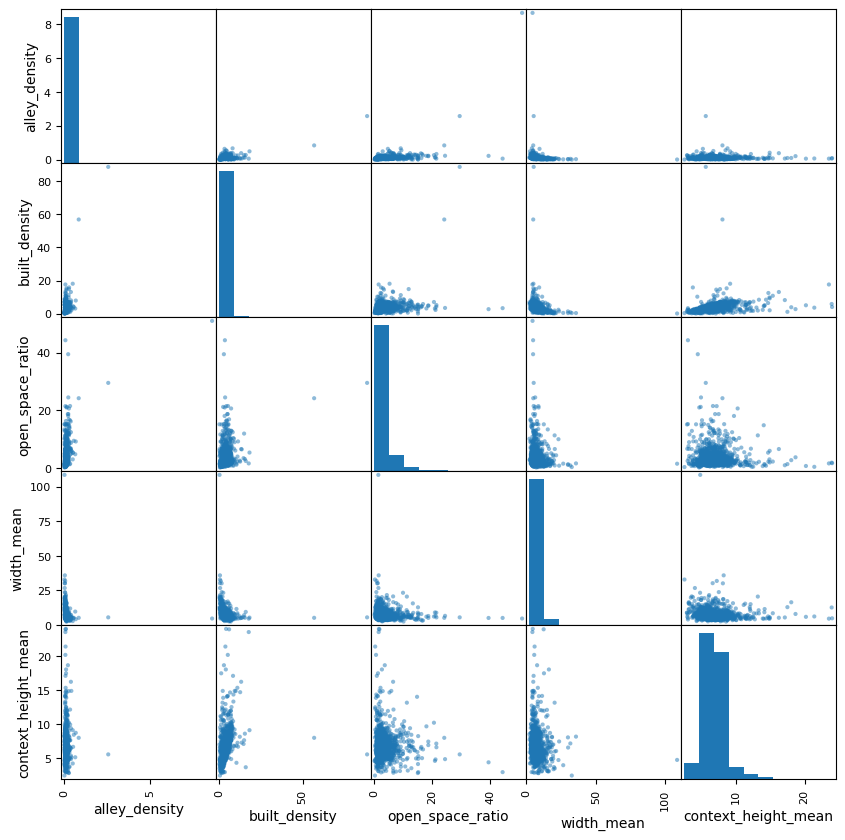

In [29]:
from pandas.plotting import scatter_matrix

scatter_matrix(
    morphology[cols],
    figsize=(10,10),
    diagonal="hist",
)

# 6. Temporal sensitivity of the inferred pedestrian network

The objective of this section is not to quantify urban growth, but to evaluate the temporal consistency of the inferred pedestrian network across independent LiDAR acquisitions.

Changes observed between different years may reflect two distinct processes:

1. genuine changes in the built environment and pedestrian infrastructure;
2. differences in acquisition characteristics, including flight altitude, scan angle, point density and other mission parameters.

Rather than attempting to fully separate these effects, this analysis aims to understand the sensitivity of the proposed framework to different airborne LiDAR surveys and to identify the conditions under which the inferred pedestrian network remains consistent.

In [30]:
temporal = (
    tables["centerline"]
    .pivot(
        index="favela",
        columns="year",
        values="alley_length",
    )
)

temporal.head()

year,2017,2020,2024
favela,,,
000001_fumaça,1585.285782,461.019819,1557.860003
000002_manuel_antônio_portella,3486.545036,3081.251782,2708.550762
000003_santa_amélia,1142.966979,497.695003,282.733379
000004_giovanni_carnovali,496.860560,440.318890,355.035568
000005_favela_das_torres,963.552401,934.291571,1546.233148


Text(0, 0.5, '2020 (km)')

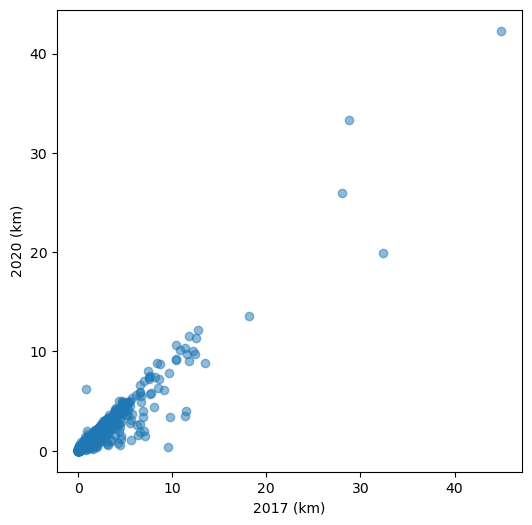

In [31]:
plt.figure(figsize=(6,6))

plt.scatter(
    temporal[2017]/1000,
    temporal[2020]/1000,
    alpha=.5,
)

plt.xlabel("2017 (km)")
plt.ylabel("2020 (km)")

Text(0, 0.5, '2024 (km)')

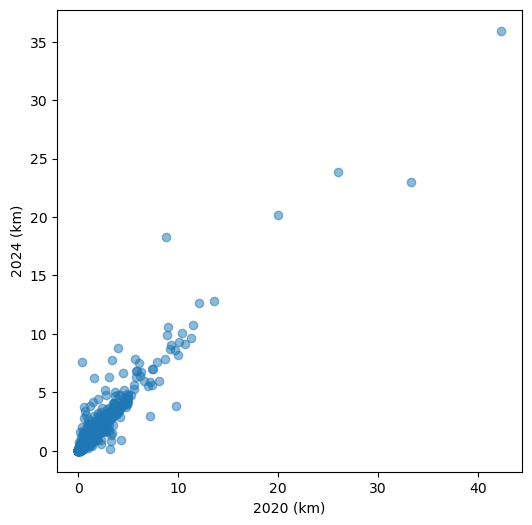

In [32]:
plt.figure(figsize=(6,6))

plt.scatter(
    temporal[2020]/1000,
    temporal[2024]/1000,
    alpha=.5,
)

plt.xlabel("2020 (km)")
plt.ylabel("2024 (km)")

Text(0, 0.5, '2024 (km)')

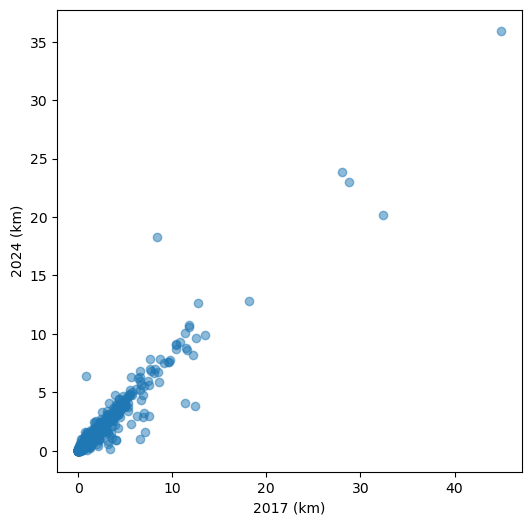

In [33]:
plt.figure(figsize=(6,6))

plt.scatter(
    temporal[2017]/1000,
    temporal[2024]/1000,
    alpha=.5,
)

plt.xlabel("2017 (km)")
plt.ylabel("2024 (km)")

In [34]:
(
    temporal[2020]
    - temporal[2017]
).describe()

count     1712.000000
mean      -189.717425
std        732.961652
min     -12481.569320
25%       -129.400349
50%        -38.011754
75%          5.420883
max       5331.481330
dtype: float64

In [35]:
(
    temporal[2024]
    - temporal[2020]
).describe()

count     1712.000000
mean       -29.922043
std        622.809044
min     -10309.136974
25%       -107.387422
50%        -23.793756
75%         23.856726
max       9474.053301
dtype: float64

(array([  1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   1.,   1.,   0.,   0.,   0.,   1.,   0.,
          1.,   0.,   0.,   2.,   4.,   0.,   1.,   3.,   3.,   2.,   3.,
          6.,   6.,   8.,   7.,  17.,  24.,  37.,  90., 900., 571.,  14.,
          5.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   1.,   0.,   1.]),
 array([-1.24815693e+04, -1.21846851e+04, -1.18878010e+04, -1.15909168e+04,
        -1.12940326e+04, -1.09971484e+04, -1.07002643e+04, -1.04033801e+04,
        -1.01064959e+04, -9.80961172e+03, -9.51272755e+03, -9.21584337e+03,
        -8.91895919e+03, -8.62207501e+03, -8.32519084e+03, -8.02830666e+03,
        -7.73142248e+03, -7.43453830e+03, -7.13765413e+03, -6.84076995e+03,
        -6.54388577e+03, -6.24700159e+03, -5.95011742e+03, -5.65323324e+03,
        -5.35634906e+03, -5.05946488e+03, -4.76258071e+03, -4.46569653e+03,
        -4.16881235e+03, -3.87192817e+03, -3.57504400e+03,

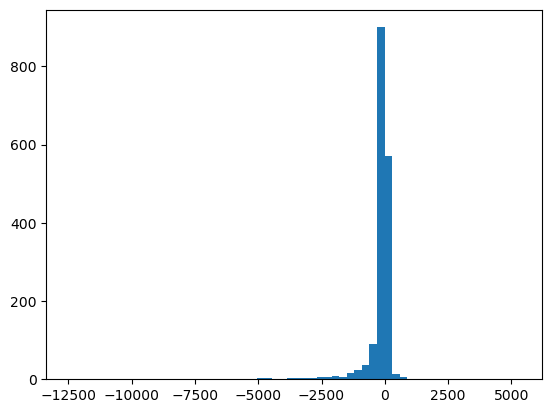

In [36]:
delta_17_20 = temporal[2020] - temporal[2017]

plt.hist(
    delta_17_20,
    bins=60,
)

([<matplotlib.axis.XTick at 0x32916c860>,
 [Text(1, 0, '17→20'), Text(2, 0, '20→24'), Text(3, 0, '17→24')])

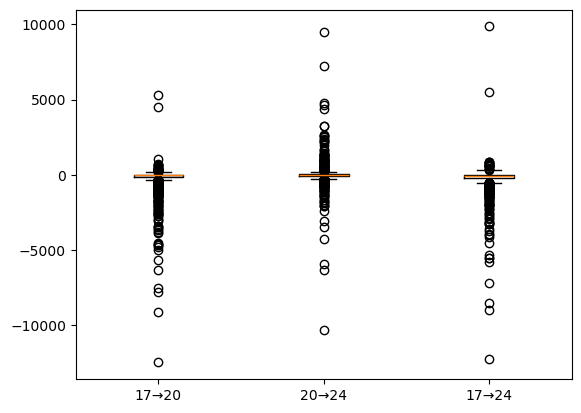

In [37]:
plt.boxplot([
    temporal[2020]-temporal[2017],
    temporal[2024]-temporal[2020],
    temporal[2024]-temporal[2017],
])

plt.xticks(
    [1,2,3],
    [
        "17→20",
        "20→24",
        "17→24",
    ]
)

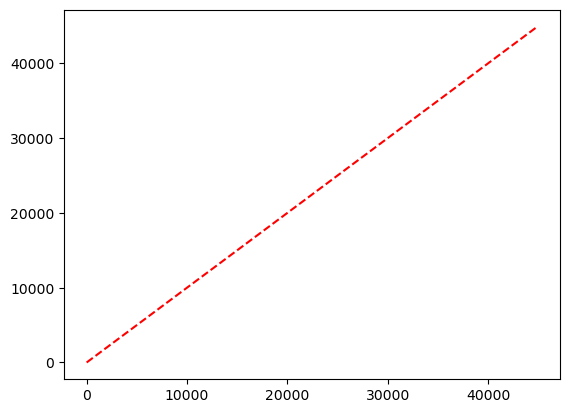

In [38]:
m = max(
    temporal[2017].max(),
    temporal[2020].max(),
)

plt.plot(
    [0,m],
    [0,m],
    "--",
    color="red",
)

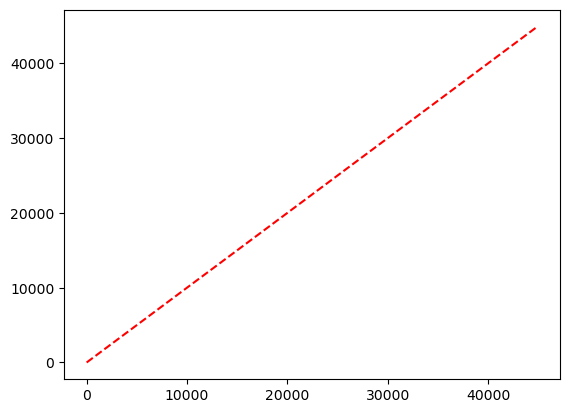

In [39]:
m = max(
    temporal[2017].max(),
    temporal[2024].max(),
)

plt.plot(
    [0,m],
    [0,m],
    "--",
    color="red",
)

In [40]:
delta_pct_17_20 = (
    (temporal[2020] - temporal[2017])
    / temporal[2017]
) * 100

In [41]:
temporal_summary = (
    centerline
    .groupby("year")
    .agg(
        total_network_km=("network_length", lambda x: x.sum()/1000),
        total_alley_km=("alley_length", lambda x: x.sum()/1000),

        mean_alley_length=("alley_length", "mean"),
        median_alley_length=("alley_length", "median"),

        mean_width=("width_mean", "mean"),
        median_width=("width_median", "median"),

        mean_context=("context_height_mean", "mean"),
        median_context=("context_height_median", "median"),
    )
)

temporal_summary.round(2)

,total_network_km,total_alley_km,mean_alley_length,median_alley_length,mean_width,median_width,mean_context,median_context
year,,,,,,,,
2017,3836.28,2113.66,1234.62,536.66,6.05,3.61,7.76,6.22
2020,3633.66,1788.87,1044.90,481.05,6.90,4.12,6.84,6.33
2024,3556.85,1737.64,1014.98,463.33,6.87,4.12,6.97,6.50


In [42]:
for year in [2017, 2020, 2024]:

    print(f"\n{year}")

    display(
        centerline
        .query("year == @year")["alley_length"]
        .describe(
            percentiles=[
                .10,
                .25,
                .50,
                .75,
                .90,
                .95,
            ]
        )
    )


2017


count     1712.000000
mean      1234.616024
std       2381.318409
min          0.000000
10%         92.528337
25%        213.358139
50%        536.659736
75%       1315.665975
90%       2988.711638
95%       4398.455732
max      44927.039453
Name: alley_length, dtype: float64


2020


count     1712.000000
mean      1044.898599
std       2064.857156
min          0.000000
10%         85.719214
25%        195.712593
50%        481.050184
75%       1110.563807
90%       2487.770798
95%       3623.977692
max      42306.805553
Name: alley_length, dtype: float64


2024


count     1712.000000
mean      1014.976556
std       1919.041482
min          0.000000
10%         78.343299
25%        176.672909
50%        463.328811
75%       1117.905584
90%       2346.946112
95%       3604.996897
max      35949.473570
Name: alley_length, dtype: float64

In [44]:
summary_by_year = (
    centerline
    .groupby("year")
    .agg(
        total_network_km=("network_length", lambda x: x.sum()/1000),
        total_alley_km=("alley_length", lambda x: x.sum()/1000),
        mean_width=("width_mean", "mean"),
        median_width=("width_median", "median"),
        mean_context=("context_height_mean", "mean"),
    )
)

summary_by_year.round(2)

,total_network_km,total_alley_km,mean_width,median_width,mean_context
year,,,,,
2017,3836.28,2113.66,6.05,3.61,7.76
2020,3633.66,1788.87,6.90,4.12,6.84
2024,3556.85,1737.64,6.87,4.12,6.97


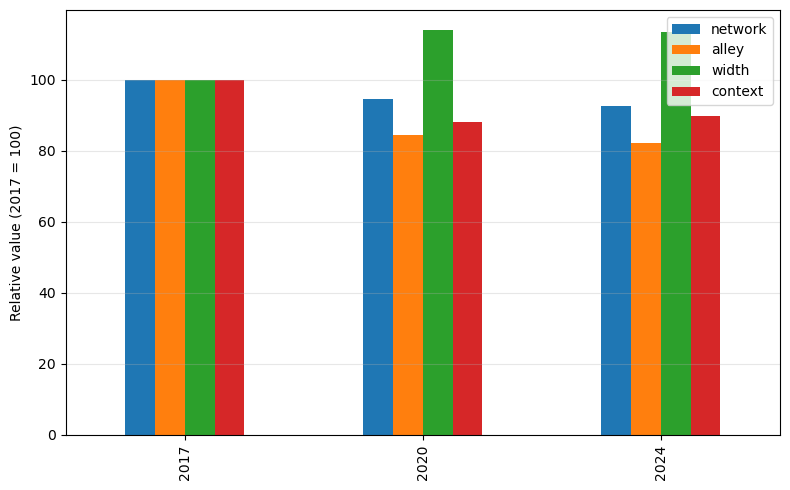

In [45]:
summary_plot = summary_by_year.copy()

summary_plot["network"] = (
    summary_plot["total_network_km"]
    / summary_plot.loc[2017, "total_network_km"]
    * 100
)

summary_plot["alley"] = (
    summary_plot["total_alley_km"]
    / summary_plot.loc[2017, "total_alley_km"]
    * 100
)

summary_plot["width"] = (
    summary_plot["mean_width"]
    / summary_plot.loc[2017, "mean_width"]
    * 100
)

summary_plot["context"] = (
    summary_plot["mean_context"]
    / summary_plot.loc[2017, "mean_context"]
    * 100
)

summary_plot[
    ["network","alley","width","context"]
].plot.bar(
    figsize=(8,5)
)

plt.ylabel("Relative value (2017 = 100)")
plt.xlabel("")
plt.grid(axis="y", alpha=.3)
plt.tight_layout()

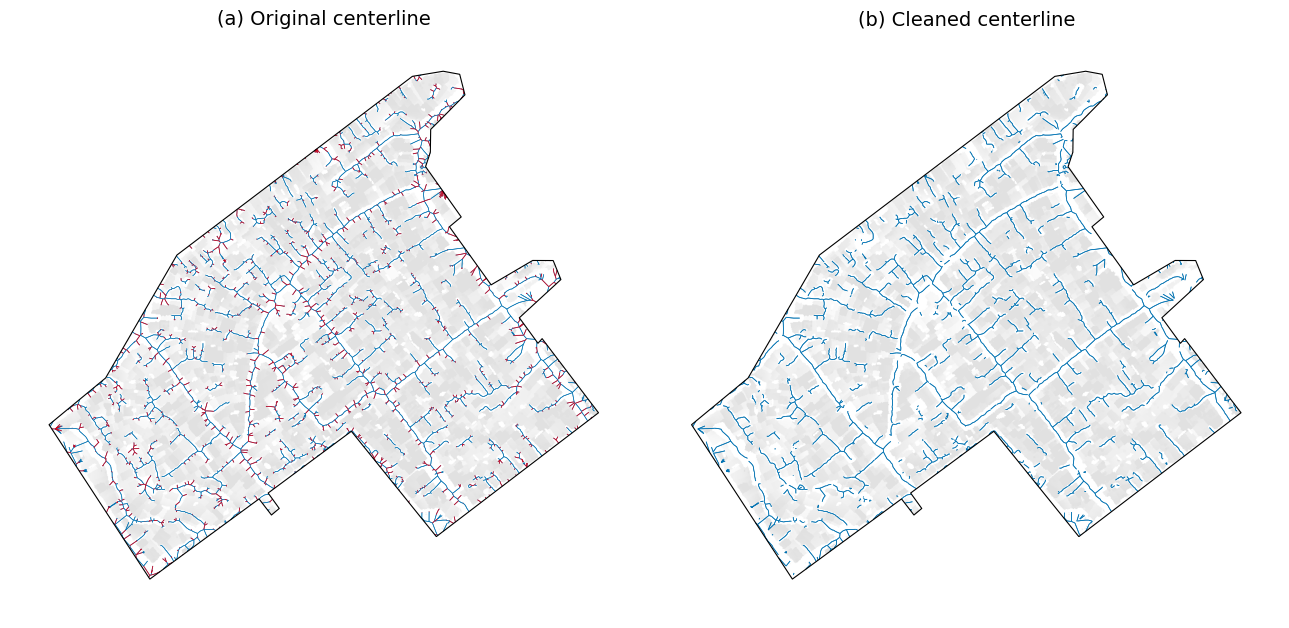

In [ ]:
from pathlib import Path

import geopandas as gpd
import rasterio
import numpy as np

import matplotlib.pyplot as plt

from shapely.ops import unary_union

# -------------------------------------------------------
# Dataset
# -------------------------------------------------------

FAVELA = "000542_são_remo"
YEAR = 2020

dataset = (
    Path("output/datasets")
    / FAVELA
    / str(YEAR)
)

background_file = dataset / "occupied_hag.tif"

network_file = dataset / "centerline_network.gpkg"

# -------------------------------------------------------
# Dados
# -------------------------------------------------------

network = gpd.read_file(network_file)

network_original = network.copy()

network_clean = network[
    ~network["tail_candidate"]
].copy()

network_original = gpd.clip(
    network_original,
    aoi
)

network_clean = gpd.clip(
    network_clean,
    aoi
)

with rasterio.open(background_file) as src:

    background = src.read(1)

    transform = src.transform

    extent = (
        transform.c,
        transform.c + src.width * transform.a,
        transform.f + src.height * transform.e,
        transform.f,
    )

# -------------------------------------------------------
# Figura
# -------------------------------------------------------

fig, axes = plt.subplots(

    1,
    2,

    figsize=(13,7),

    sharex=True,
    sharey=True,

)

titles = [

    "(a) Original centerline",
    "(b) Cleaned centerline",

]

for ax, title, gdf in zip(

    axes,

    titles,

    [network_original, network_clean],

):

    ax.imshow(

        background,

        extent=extent,

        origin="upper",

        cmap="Greys",

        alpha=0.12,

        vmin=0,

        vmax=np.nanpercentile(background,95),

    )

    gdf.plot(

        ax=ax,

        color="#0072B2",

        linewidth=0.45,

        alpha=0.95,

    )

    ax.set_title(

        title,

        fontsize=14,

    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():

        spine.set_visible(False)

plt.tight_layout()

removed = gpd.clip(

    network[
        network["tail_candidate"]
    ],

    aoi,

)

network_clean.plot(

    ax=axes[0],

    color="#0072B2",

    linewidth=0.45,

    alpha=0.95,

)

removed.plot(

    ax=axes[0],

    color="#D50019",

    linewidth=0.60,

    alpha=0.95,

)

network_clean.plot(

    ax=axes[1],

    color="#0072B2",

    linewidth=0.60,

    alpha=0.95,

)

for ax in axes:

    aoi.boundary.plot(

        ax=ax,

        color="black",

        linewidth=0.8,

        zorder=20,

    )

plt.show()

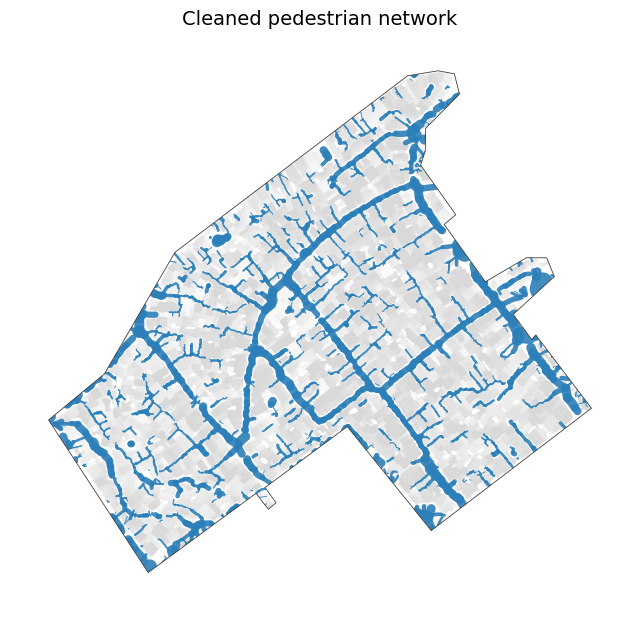

In [104]:
from pathlib import Path

import geopandas as gpd
import rasterio
import numpy as np

import matplotlib.pyplot as plt

# -------------------------------------------------------
# Dataset
# -------------------------------------------------------

FAVELA = "000542_são_remo"
YEAR = 2020

dataset = (
    Path("output/datasets")
    / FAVELA
    / str(YEAR)
)

background_file = dataset / "occupied_hag.tif"

network_file = dataset / "centerline_network.gpkg"

# -------------------------------------------------------
# Dados
# -------------------------------------------------------

network = gpd.read_file(network_file)

network_original = network.copy()

network_clean = network[
    ~network["tail_candidate"]
].copy()

network_original = gpd.clip(
    network_original,
    aoi
)

network_clean = gpd.clip(
    network_clean,
    aoi
)

# -------------------------------------------------------
# Buffer (half width)
# -------------------------------------------------------

network_original_buffer = network_original.copy()

network_original_buffer.geometry = network_original_buffer.buffer(
    network_original_buffer.width_median * 0.35,
    cap_style=1,
    join_style=1,
)

network_clean_buffer = network_clean.copy()

network_clean_buffer.geometry = network_clean_buffer.buffer(
    network_clean_buffer.width_median * 0.35,
    cap_style=1,
    join_style=1,
)

network_clean_buffer = gpd.clip(
    network_clean_buffer,
    aoi,
)

removed_buffer = removed.copy()

removed_buffer.geometry = removed_buffer.buffer(
    removed_buffer.width_median / 2,
    cap_style=1,
    join_style=1,
)

with rasterio.open(background_file) as src:

    background = src.read(1)

    transform = src.transform

    extent = (
        transform.c,
        transform.c + src.width * transform.a,
        transform.f + src.height * transform.e,
        transform.f,
    )

# -------------------------------------------------------
# Figura
# -------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8,8)
)

titles = [

    "(a) Original centerline",
    "(b) Cleaned centerline",

]

ax.imshow(
    background,
    extent=extent,
    origin="upper",
    cmap="Greys",
    alpha=0.15,
    vmin=0,
    vmax=np.nanpercentile(background,95),
)

network_clean_buffer.plot(
    ax=ax,
    color="#2C7FB8",
    edgecolor="none",
    alpha=0.90,
)

removed = gpd.clip(

    network[
        network["tail_candidate"]
    ],

    aoi,

)

network_clean_buffer.plot(
    ax=axes[0],
    color="#0072B2",
    linewidth=0.45,
    alpha=0.95,
)

removed_buffer.plot(
    ax=axes[0],
    color="#D50019",
    linewidth=0.60,
    alpha=0.95,
)

network_clean.plot(
    ax=axes[1],
    color="#0072B2",
    linewidth=0.60,
    alpha=0.95,
)

aoi.boundary.plot(
    ax=ax,
    color="#404040",
    linewidth=0.6,
    zorder=20,
)

ax.set_title(
    "Cleaned pedestrian network",
    fontsize=14,
)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.show()

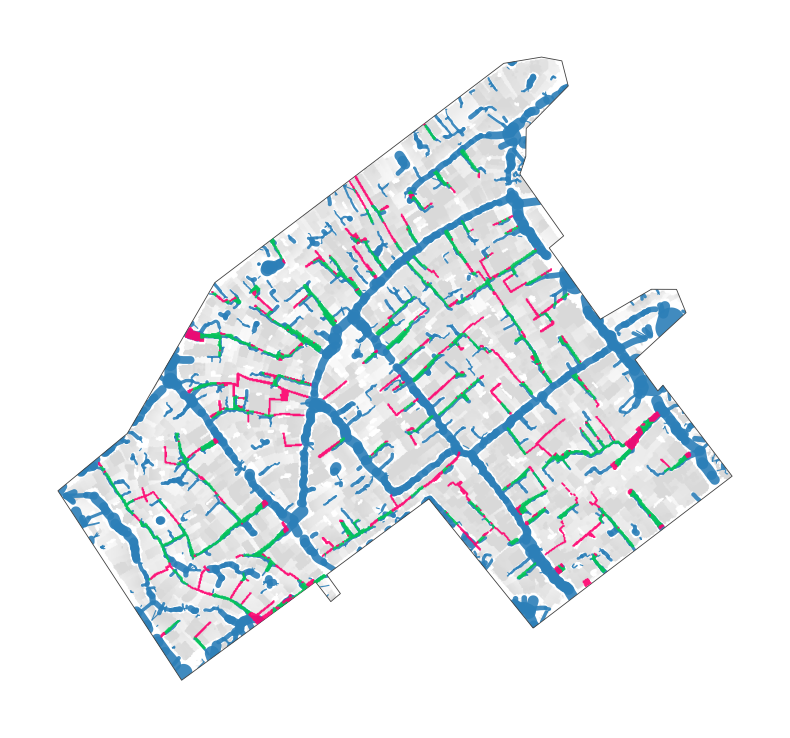

In [108]:
from pathlib import Path

import geopandas as gpd
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from rasterio.features import shapes
from shapely.geometry import shape


# -------------------------------------------------------
# Dataset
# -------------------------------------------------------

FAVELA = "000542_são_remo"
YEAR = 2020

dataset = (
    Path("output/datasets")
    / FAVELA
    / str(YEAR)
)

background_file = dataset / "occupied_hag.tif"
network_file = dataset / "centerline_network.gpkg"
validation_file = dataset / "validation_classes.tif"

# -------------------------------------------------------
# Data
# -------------------------------------------------------

network = gpd.read_file(network_file)

network = network[
    ~network.tail_candidate
].copy()

network = gpd.clip(
    network,
    aoi,
)

tp_cmap = ListedColormap(["#2ca25f"])   # verde
fn_cmap = ListedColormap(["#d81b60"])   # magenta

# -------------------------------------------------------
# Buffer
# -------------------------------------------------------

network.geometry = network.buffer(
    network.width_median * 0.35,
    cap_style=1,
    join_style=1,
)

network = gpd.clip(
    network,
    aoi,
)

# -------------------------------------------------------
# Rasters
# -------------------------------------------------------

with rasterio.open(background_file) as src:

    background = src.read(1)

    transform = src.transform

    extent = (
        transform.c,
        transform.c + src.width * transform.a,
        transform.f + src.height * transform.e,
        transform.f,
    )

with rasterio.open(validation_file) as src:

    validation = src.read(1)


records = []

for geom, value in shapes(
    validation.astype(np.int16),
    transform=transform,
):

    if value in (1, 3):

        records.append(
            {
                "class": int(value),
                "geometry": shape(geom),
            }
        )

validation_gdf = gpd.GeoDataFrame(
    records,
    crs=network.crs,
)

# -------------------------------------------------------
# Validation masks
# -------------------------------------------------------

tp = validation_gdf[
    validation_gdf["class"] == 1
].copy()

fn = validation_gdf[
    validation_gdf["class"] == 3
].copy()

tp = tp.dissolve()

fn = fn.dissolve()

tp.geometry = tp.buffer(0.30)

fn.geometry = fn.buffer(0.30)

tp = tp.clip(aoi)

fn = fn.clip(aoi)

# -------------------------------------------------------
# Figure
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(8,8))

ax.imshow(
    background,
    extent=extent,
    origin="upper",
    cmap="Greys",
    alpha=0.15,
    vmin=0,
    vmax=np.nanpercentile(background,95),
)

network.plot(
    ax=ax,
    color="#2C7FB8",
    edgecolor="none",
    alpha=0.90,
)

tp.plot(
    ax=ax,
    color="#00C853",
    edgecolor="none",
    alpha=0.90,
    zorder=15,
)

fn.plot(
    ax=ax,
    color="#FF006E",
    edgecolor="none",
    alpha=0.90,
    zorder=16,
)

aoi.boundary.plot(
    ax=ax,
    color="#404040",
    linewidth=0.6,
)

ax.set_xticks([])
ax.set_yticks([])

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()